# Fase 4 (parte B) — CNN desde cero
**Proyecto:** FruitVision — Clasificación de Calidad de Frutas

---
Red neuronal convolucional **entrenada desde cero** (sin transfer learning),
como recomienda el enunciado. Arquitectura pequeña apta para CPU:
3 bloques convolucionales (Conv→BatchNorm→MaxPool) + capa densa + Dropout.

Incluye:
- **Data augmentation** (flip, rotación, zoom, brillo) como capas de Keras.
- **`class_weight`** para el desbalanceo residual.
- **Callbacks**: `EarlyStopping` + `ReduceLROnPlateau`.

In [1]:
# Bootstrap
import sys, pathlib, os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
ROOT = pathlib.Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

from src.config import QUALITY_CLASSES, CNN_IMG_SIZE, MODELS_DIR, FIGURES_DIR, SEED
from src.data.preprocessing import load_manifest
from src.data.paths import load_image_rgb
tf.random.set_seed(SEED); np.random.seed(SEED)
print("TF", tf.__version__, "| img size", CNN_IMG_SIZE)

I0000 00:00:1780425257.725160  140978 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1780425260.338670  140978 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TF 2.21.0 | img size (96, 96)


## 1. Cargar imágenes en memoria
Las imágenes (96×96) caben en RAM, lo que evita cuellos de I/O en CPU.

In [2]:
import cv2
def load_split(split):
    m = load_manifest(split)
    X = np.zeros((len(m), *CNN_IMG_SIZE, 3), np.float32)
    keep = np.ones(len(m), bool)
    for i, p in enumerate(m['abs_path']):
        img = load_image_rgb(p)
        if img is None: keep[i] = False; continue
        X[i] = cv2.resize(img, CNN_IMG_SIZE).astype(np.float32) / 255.0
    y = m['quality_idx'].values
    return X[keep], y[keep]

Xtr, ytr = load_split('train')
Xva, yva = load_split('val')
Xte, yte = load_split('test')
print("train", Xtr.shape, "| val", Xva.shape, "| test", Xte.shape)
print("clases:", dict(enumerate(QUALITY_CLASSES)))

train (2851, 96, 96, 3) | val (611, 96, 96, 3) | test (612, 96, 96, 3)
clases: {0: 'Premium', 1: 'Estándar', 2: 'Descarte'}


## 2. Arquitectura de la CNN

In [3]:
data_aug = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomBrightness(0.10, value_range=(0,1)),
], name="augmentation")

def build_cnn():
    m = models.Sequential([
        layers.Input((*CNN_IMG_SIZE, 3)),
        data_aug,
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(len(QUALITY_CLASSES), activation='softmax'),
    ], name="FruitCNN")
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

cnn = build_cnn()
cnn.summary()

E0000 00:00:1780425275.168493  140978 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.


Model: "FruitCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,043 (433.76 KB)

 Trainable params: 110,595 (432.01 KB)

 Non-trainable params: 448 (1.75 KB)

## 3. Entrenamiento
`class_weight` compensa el desbalanceo; callbacks evitan sobreajuste y ajustan el LR.

In [4]:
cw = compute_class_weight('balanced', classes=np.unique(ytr), y=ytr)
class_weight = dict(enumerate(cw))
print("class_weight:", {QUALITY_CLASSES[k]: round(v,2) for k,v in class_weight.items()})

cbs = [
    callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5),
]
history = cnn.fit(Xtr, ytr, validation_data=(Xva, yva),
                  epochs=40, batch_size=32, class_weight=class_weight,
                  callbacks=cbs, verbose=2)

class_weight: {'Premium': np.float64(0.91), 'Estándar': np.float64(1.27), 'Descarte': np.float64(0.91)}


Epoch 1/40


90/90 - 34s - 378ms/step - accuracy: 0.7043 - loss: 0.7191 - val_accuracy: 0.5499 - val_loss: 0.9445 - learning_rate: 0.0010


Epoch 2/40


90/90 - 32s - 359ms/step - accuracy: 0.7924 - loss: 0.5522 - val_accuracy: 0.5663 - val_loss: 0.9495 - learning_rate: 0.0010


...

90/90 - 30s - 329ms/step - accuracy: 0.9548 - loss: 0.1405 - val_accuracy: 0.9116 - val_loss: 0.2428 - learning_rate: 6.2500e-05


Epoch 31/40


90/90 - 29s - 326ms/step - accuracy: 0.9519 - loss: 0.1341 - val_accuracy: 0.8920 - val_loss: 0.2769 - learning_rate: 6.2500e-05


Epoch 32/40


90/90 - 29s - 325ms/step - accuracy: 0.9590 - loss: 0.1320 - val_accuracy: 0.8985 - val_loss: 0.2840 - learning_rate: 6.2500e-05


## 4. Curvas de aprendizaje

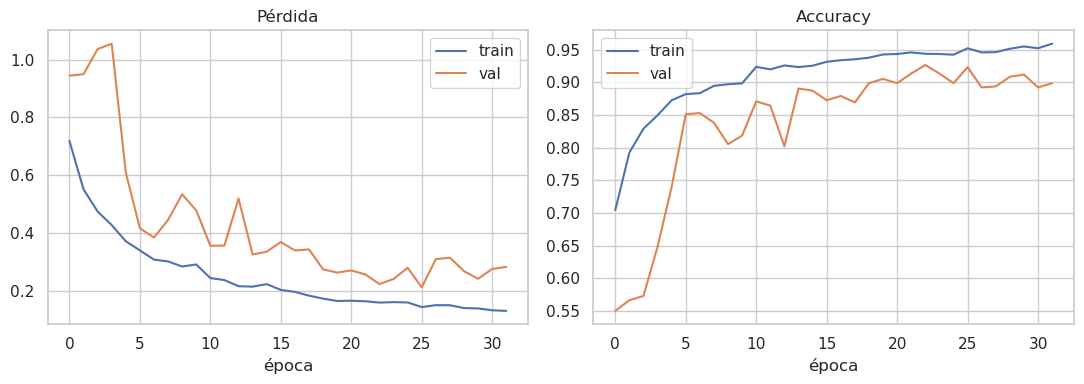

In [5]:
h = history.history
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(h['loss'], label='train'); ax[0].plot(h['val_loss'], label='val')
ax[0].set_title('Pérdida'); ax[0].set_xlabel('época'); ax[0].legend()
ax[1].plot(h['accuracy'], label='train'); ax[1].plot(h['val_accuracy'], label='val')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('época'); ax[1].legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fase4_cnn_curvas.pdf", bbox_inches="tight")
plt.show()

## 5. Evaluación en prueba

CNN  ->  accuracy=0.908 | f1_macro=0.908

              precision    recall  f1-score   support

     Premium      0.965     0.849     0.903       225
    Estándar      0.833     0.988     0.904       162
    Descarte      0.923     0.911     0.917       225

    accuracy                          0.908       612
   macro avg      0.907     0.916     0.908       612
weighted avg      0.915     0.908     0.909       612



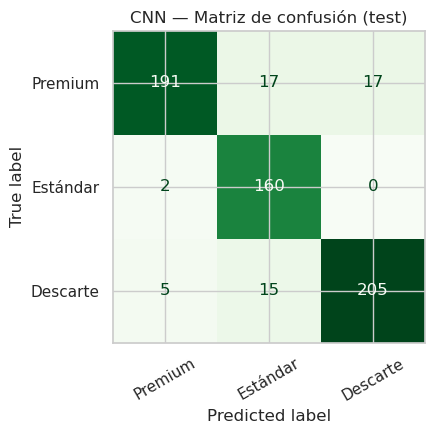

In [6]:
proba = cnn.predict(Xte, verbose=0)
pred = proba.argmax(1)
acc = accuracy_score(yte, pred); f1 = f1_score(yte, pred, average='macro')
print(f"CNN  ->  accuracy={acc:.3f} | f1_macro={f1:.3f}\n")
print(classification_report(yte, pred, target_names=QUALITY_CLASSES, digits=3))

cm = confusion_matrix(yte, pred)
fig, axx = plt.subplots(figsize=(5,4.5))
ConfusionMatrixDisplay(cm, display_labels=QUALITY_CLASSES).plot(ax=axx, cmap='Greens', colorbar=False)
axx.set_title('CNN — Matriz de confusión (test)'); axx.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fase4_cnn_confusion.pdf", bbox_inches="tight")
plt.show()

## 6. Guardado del modelo

In [7]:
cnn.save(MODELS_DIR / "cnn_quality.keras")
print("Modelo guardado en models/saved/cnn_quality.keras")
pd.DataFrame({'modelo':['CNN'],'accuracy':[acc],'f1_macro':[f1]}).to_csv(
    MODELS_DIR / "cnn_metrics.csv", index=False)

Modelo guardado en models/saved/cnn_quality.keras


## Resumen
- CNN **desde cero** (3 bloques conv) con augmentation y regularización (BatchNorm + Dropout).
- `class_weight` + callbacks (`EarlyStopping`, `ReduceLROnPlateau`).
- Modelo guardado para el despliegue.

➡️ **Siguiente:** Fase 5 — Evaluación comparativa (ML vs CNN vs baseline) y Fase 6 (app).